**Credit Card Fraud Detection**

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


In [122]:
df=pd.read_csv("creditcard.csv")

In [123]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [124]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [125]:
# check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [126]:
# number of legit transactions and fradulent transactions(284315-legit, 492-fradulent)
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

0 284315
1 492

In [127]:
legit=df[df.Class==0]
fraud=df[df.Class==1]

In [128]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [129]:
# statistical measures about the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [130]:
fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

*mean transaction of legit is less than the mean transaction of fraud*

In [131]:
#  compare the values for both the transactions
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


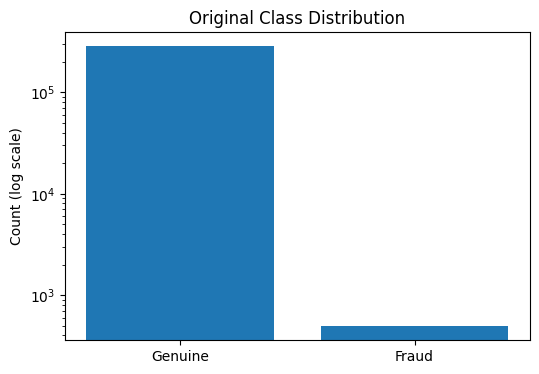

In [132]:
import matplotlib.pyplot as plt

class_count = df['Class'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ['Genuine', 'Fraud'],
    class_count.values
)

plt.yscale('log')   # makes fraud visible

plt.title("Original Class Distribution")
plt.ylabel("Count (log scale)")

plt.show()

In [133]:
X = df.drop(columns='Class')

Y = df['Class']


In [134]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(
    X[['Amount']]
)


In [135]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)


In [136]:
print("\nApplying SMOTE...\n")

smote = SMOTE(random_state=2)

X_train, Y_train = smote.fit_resample(
    X_train,
    Y_train
)


Applying SMOTE...



In [137]:
print("Balanced Class Distribution:\n")

print(Y_train.value_counts())

Balanced Class Distribution:

Class
0    227451
1    227451
Name: count, dtype: int64


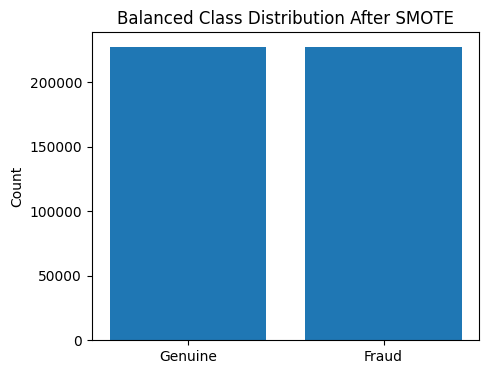

In [138]:
balanced_count = Y_train.value_counts()

plt.figure(figsize=(5, 4))

plt.bar(
    ['Genuine', 'Fraud'],
    balanced_count.values
)

plt.title("Balanced Class Distribution After SMOTE")

plt.ylabel("Count")

plt.show()

In [143]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

print("\nModel Trained Successfully")




Model Trained Successfully


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [144]:
test_prediction = model.predict(X_test)

test_accuracy = accuracy_score(Y_test,test_prediction)
print("\nTesting Accuracy:", test_accuracy)


Testing Accuracy: 0.9906604402935291


In [145]:
# Classification Report
print("\nClassification Report:\n")

print(classification_report(Y_test,test_prediction))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.15      0.93      0.25        98

    accuracy                           0.99     56962
   macro avg       0.57      0.96      0.63     56962
weighted avg       1.00      0.99      0.99     56962

